In [2]:
%pip install --quiet -U langchain_aws langchain_core langgraph
%pip install --upgrade python-dotenv


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

os.environ["AWS_ACCESS_KEY_ID"] = os.getenv('AWS_ACCESS_KEY_ID')
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv('AWS_SECRET_ACCESS_KEY')
os.environ["AWS_DEFAULT_REGION"] =os.getenv('AWS_DEFAULT_REGION')

In [4]:
os.environ["LANGSMITH_TRACING"] = os.getenv("LANGSMITH_TRACING", "true")
os.environ["LANGSMITH_ENDPOINT"] = os.getenv("LANGSMITH_ENDPOINT", "https://api.smith.langchain.com")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY", "")
os.environ["LANGSMITH_PROJECT"] = "day-3-lab1"

In [5]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, AnyMessage

prepared message for conversations

In [6]:
messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Vijay"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the India.", name="Vijay"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Vijay

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Vijay

I want to learn about the best place to see Orcas in the India.


Configure the LLM model  for conversation

In [7]:
from langchain_aws import ChatBedrock
# --- Chat Model ---
llm = ChatBedrock(
    model_id="amazon.nova-lite-v1:0",
    temperature=1,
)
result = llm.invoke("hello")
print(result)

content="Hello! How can I help you today? If you have any questions or need assistance, feel free to ask and I'll do my best to provide you with helpful information and support. Whether you're looking for advice, information on a particular topic, or just want to chat, I'm here to assist you. So, what's on your mind?" additional_kwargs={} response_metadata={'ResponseMetadata': {'RequestId': 'ba2edbc8-8d22-47f3-8a6b-f884381c6778', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Fri, 13 Mar 2026 05:40:28 GMT', 'content-type': 'application/json', 'content-length': '510', 'connection': 'keep-alive', 'x-amzn-requestid': 'ba2edbc8-8d22-47f3-8a6b-f884381c6778'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [488]}, 'model_provider': 'bedrock_converse', 'model_name': 'amazon.nova-lite-v1:0'} id='lc_run--019ce5b5-d9bc-7e70-ac08-7edbe7aad84d-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 1, 'output_tokens': 76, 'total_tokens': 77, 'input_token_de

Define State with messages

from typing_extensions import TypedDict

class MessageState(TypedDict):
    messages: list[AnyMessage]

Reducers- where atutomatically append all the message 

In [8]:
from typing import  List,  TypedDict, Annotated,operator, Literal

from typing_extensions import TypedDict
from langgraph.graph import MessagesState # messages[data memeber] add_messages [method used for adding the messages]

class MessageState(MessagesState):
    pass
    #messages: Annotated[list[AnyMessage], operator.add]

In [9]:
from langgraph.graph.message import add_messages

initial_messages = [
    HumanMessage(content="hi", name="vijay"),
    AIMessage(content="hello! how can i assist you")
]
new_prompt = "what is the best place to see orcas in india?"

update_message = add_messages(initial_messages, new_prompt)

print(update_message)

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, name='vijay', id='4131235b-1c47-4557-a3be-30a52dec35f6'), AIMessage(content='hello! how can i assist you', additional_kwargs={}, response_metadata={}, id='fba8a37c-af15-4bdf-89e2-60d289fd7eb1', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='what is the best place to see orcas in india?', additional_kwargs={}, response_metadata={}, id='0c8ed514-e131-4a13-aed9-ec0d8ae1514c')]


Tools: for fetching addtional context for your prompt you can use a tool 
        or 
       do an action on external system [servicenow [ticket]]

In [10]:

#tool1 multiplication of two numbers
def multiply(a: int,b: int) -> int:
    """ Multiply a and b.
    Args:
        a: int
        b: int
    """
    return a * b

# tool2 add of 2 numbers 
def addition(a: int,b: int) -> int:
    """ add a and b.
    Args:
        a: int
        b: int
    """
    return a + b 

llm_with_tools = llm.bind_tools([multiply, addition])

In [11]:
result = llm_with_tools.invoke("what is the sum of 5 and 10")

In [12]:
print(result.content)

[{'type': 'text', 'text': "<thinking>The User's request is to find the sum of two numbers, 5 and 10. I can use the addition tool to perform this operation.</thinking>\n"}, {'type': 'tool_use', 'name': 'addition', 'input': {'a': 5, 'b': 10}, 'id': 'tooluse_rYGFXPqRWkci7IVNCeakUj'}]


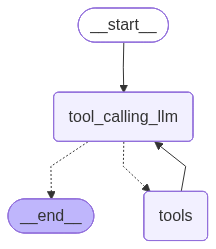

In [28]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver 

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}
        

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply, addition]))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
config= {"configurable": {"thread_id": "1"}}

messages = graph.invoke({"messages": HumanMessage(content="what is the product of 5 and 10 ")}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the product of 5 and 10 
================================== Ai Message ==================================

[{'type': 'text', 'text': "<thinking>The task is to find the product of 5 and 10. I can use the 'multiply' tool for this operation.</thinking>\n"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 5, 'b': 10}, 'id': 'tooluse_V8zW7V8m60E7AbLDTiVJdp'}]
Tool Calls:
  multiply (tooluse_V8zW7V8m60E7AbLDTiVJdp)
 Call ID: tooluse_V8zW7V8m60E7AbLDTiVJdp
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: multiply

50
================================== Ai Message ==================================

The product of 5 and 10 is 50.


In [32]:
config= {"configurable": {"thread_id": "1"}}

messages = graph.invoke({"messages": HumanMessage(content="add with 20 to that result")}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the product of 5 and 10 
================================== Ai Message ==================================

[{'type': 'text', 'text': "<thinking>The task is to find the product of 5 and 10. I can use the 'multiply' tool for this operation.</thinking>\n"}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 5, 'b': 10}, 'id': 'tooluse_V8zW7V8m60E7AbLDTiVJdp'}]
Tool Calls:
  multiply (tooluse_V8zW7V8m60E7AbLDTiVJdp)
 Call ID: tooluse_V8zW7V8m60E7AbLDTiVJdp
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: multiply

50
================================== Ai Message ==================================

The product of 5 and 10 is 50.
================================ Human Message =================================

add with 20 to that result
================================== Ai Message ==================================

[{'type': 'text',